In [1]:
from google.colab import files
files.upload()  # Upload kaggle.json file

import os, shutil

# Move kaggle.json to correct location
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

# Install and download EMNIST dataset
!pip install kaggle
!kaggle datasets download -d crawford/emnist
!unzip emnist.zip -d emnist_data

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/crawford/emnist
License(s): CC0-1.0
100% 1.24G/1.24G [00:08<00:00, 158MB/s]

Archive:  emnist.zip
  inflating: emnist_data/emnist-balanced-mapping.txt  
  inflating: emnist_data/emnist-balanced-test.csv  
  inflating: emnist_data/emnist-balanced-train.csv  
  inflating: emnist_data/emnist-byclass-mapping.txt  
  inflating: emnist_data/emnist-byclass-test.csv  
  inflating: emnist_data/emnist-byclass-train.csv  
  inflating: emnist_data/emnist-bymerge-mapping.txt  
  inflating: emnist_data/emnist-bymerge-test.csv  
  inflating: emnist_data/emnist-bymerge-train.csv  
  inflating: emnist_data/emnist-digits-mapping.txt  
  inflating: emnist_data/emnist-digits-test.csv  
  inflating: emnist_data/emnist-digits-train.csv  
  inflating: emnist_data/emnist-letters-mapping.txt  
  inflating: emnist_data/emnist-letters-test.csv  
  inflating: emnist_data/emnist-letters-train.csv  
  inflating: emnist_data/emnist-mnist-

In [2]:
import pandas as pd
import os

path = "emnist_data"

# Load CSV files
# Each row contains: label + flattened 28x28 image pixels
train = pd.read_csv(os.path.join(path, "emnist-letters-train.csv"))
test = pd.read_csv(os.path.join(path, "emnist-letters-test.csv"))

In [3]:
# DATASET PREPROCESSING (EMNIST-CHARACTER LEVEL)

import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class EMNISTDataset(Dataset):
    # X = pixel values, y = labels
    def __init__(self, df):
        self.X = df.iloc[:, 1:].values  # Extract pixel values (all columns except first)
        self.y = df.iloc[:, 0].values   # Extract labels (first column)

    # Return total number of samples
    def __len__(self):
        return len(self.X)

    # Get one sample (image + label)
    def __getitem__(self, idx):
        img = self.X[idx].reshape(28, 28).astype(np.uint8)  # Reshape flattened 784 pixels → 28x28 image

        img = np.transpose(img)                             # Fix orientation (EMNIST images are rotated by default)

        img = img / 255.0                                   # Normalize pixel values from [0,255] → [0,1]

        img = torch.tensor(img).unsqueeze(0).float()        # Convert to PyTorch tensor and add channel dimension → [1, 28, 28]

        label = int(self.y[idx]) - 1                        # Convert label range from [1–26] → [0–25] for model compatibility

        return img, label

In [4]:
# Create datasets and loaders

# Convert pandas DataFrames into custom PyTorch datasets
train_dataset = EMNISTDataset(train)
test_dataset = EMNISTDataset(test)

# Create DataLoaders to handle batching and iteration
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)  # train_loader shuffles data for better training
test_loader = DataLoader(test_dataset, batch_size=64)                  # test_loader does NOT shuffle (keeps evaluation consistent)

In [6]:
!pip install wordfreq

from wordfreq import top_n_list, zipf_frequency

In [7]:
def load_dictionary():
    print("Loading frequency-based dictionary...")

    # Top 50,000 most common English words
    words = top_n_list("en", 50000)

    dictionary = set(words)

    print(f"Loaded {len(dictionary)} common words")
    return dictionary

dictionary = load_dictionary()

Loading frequency-based dictionary...
Loaded 50000 common words


In [8]:
# MODEL DEFINITION (CHARACTER CNN)

import torch.nn as nn

class CharCNN(nn.Module):
    def __init__(self):
        super(CharCNN, self).__init__()

        # Convolution layers → extract features from character images
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, padding=1),   # First convolution layer: input channel=1 (grayscale), output=32 feature maps
            nn.BatchNorm2d(32),                  # Normalize features
            nn.ReLU(),                           # Apply ReLU for non-linearity
            nn.MaxPool2d(2),                     # Downsample (reduce size)

            nn.Conv2d(32, 64, 3, 1, padding=1),  # Second convolution layer: 32 → 64 feature maps
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, 1, padding=1), # Third convolution layer: captures fine details (important for i vs l)
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Fully connected layers → classify character
        self.fc = nn.Sequential(
            nn.Linear(128 * 3 * 3, 128),         # Flattened feature input → hidden layer
            nn.ReLU(),

            nn.Dropout(0.3),                     # Prevent overfitting (helps generalization)

            nn.Linear(128, 26)                   # Output layer (26 classes: a–z)
        )

    # Forward pass
    def forward(self, x):
        x = self.conv(x)            # Extract features from image (edges, shapes)
        x = x.view(x.size(0), -1)   # Flatten 2D feature maps → 1D vector
        return self.fc(x)           # Output prediction (26 letter classes)

In [9]:
# MODEL TRAINING (EMNIST PRETRAINING)

import torch
import torch.nn as nn

model = CharCNN()                                          # Initialize the CNN model

criterion = nn.CrossEntropyLoss()          # Loss function (multi-class classification)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # Optimizer (updates weights)

# Training loop
for epoch in range(10):
    total_loss = 0

    # Iterate over batches of training data
    for images, labels in train_loader:
        outputs = model(images)                            # Forward pass (predict outputs)
        loss = criterion(outputs, labels)                  # Compute loss

        # Backpropagation
        optimizer.zero_grad()                              # Clear previous gradients
        loss.backward()                                    # Compute gradients
        optimizer.step()                                   # Update weights

        total_loss += loss.item()                          # Sum batch losses

    # Compute average loss for the epoch
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")

# Save trained model weights to file
torch.save(model.state_dict(), "char_model.pth")

Epoch 1, Avg Loss: 0.5321
Epoch 2, Avg Loss: 0.2855
Epoch 3, Avg Loss: 0.2451
Epoch 4, Avg Loss: 0.2204
Epoch 5, Avg Loss: 0.1993
Epoch 6, Avg Loss: 0.1827
Epoch 7, Avg Loss: 0.1693
Epoch 8, Avg Loss: 0.1587
Epoch 9, Avg Loss: 0.1492
Epoch 10, Avg Loss: 0.1404


Overall Accuracy: 0.9361


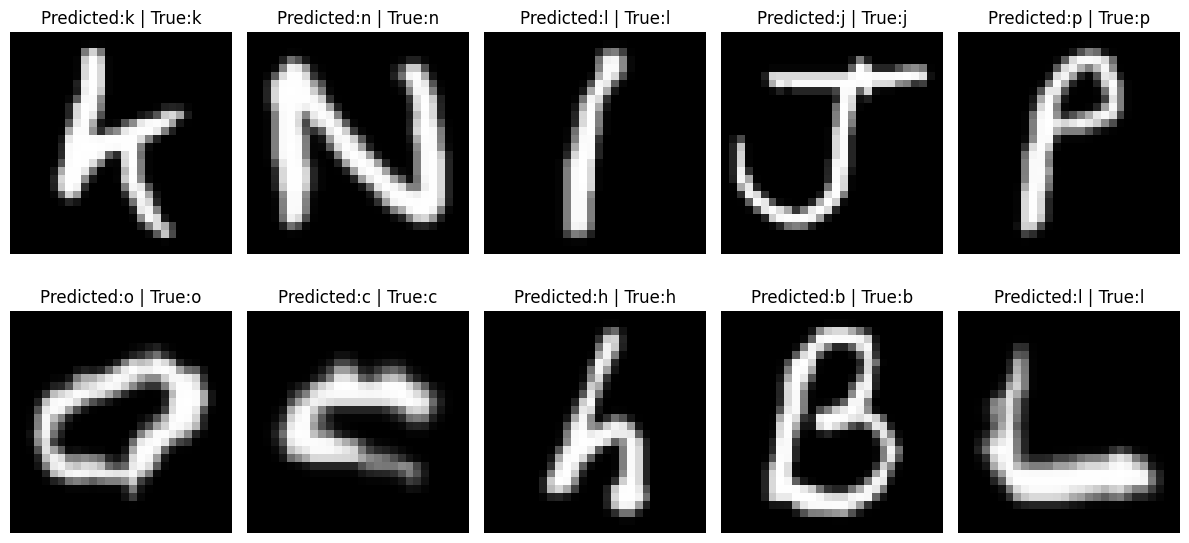

In [10]:
# MODEL EVALUATION (CHARACTER LEVEL)

import matplotlib.pyplot as plt
import random

model.eval()                                                    # Set model to evaluation mode

correct = 0
total = 0

# Store predictions and true labels for later analysis (confusion matrix)
all_preds = []
all_labels = []

# Disable gradient computation
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)                                 # Forward pass (get predictions)
        preds = torch.argmax(outputs, dim=1)                    # Get predicted class index

        # Count correct predictions
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # Store predictions and true labels
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

# Compute overall accuracy on test set
accuracy = correct / total
print(f"Overall Accuracy: {accuracy:.4f}")

# VISUAL TESTING (CHARACTER PREDICTIONS)

num_samples = 10
indices = random.sample(range(len(test_dataset)), num_samples)  # Select 10 random samples from test dataset

plt.figure(figsize=(12,6))                                      # Create figure to display images

for i, idx in enumerate(indices):
    img, label = test_dataset[idx]

    # Predict character for single image
    img_input = img.unsqueeze(0)
    output = model(img_input)
    pred = torch.argmax(output, dim=1).item()

    # Convert numeric labels (0–25) → letters (a–z)
    pred_char = chr(pred + ord('a'))
    true_char = chr(label + ord('a'))

    # Display image with predicted and true label
    plt.subplot(2,5,i+1)
    plt.imshow(img.squeeze().numpy(), cmap='gray')
    plt.title(f"Predicted:{pred_char} | True:{true_char}")
    plt.axis('off')

plt.tight_layout()
plt.show()

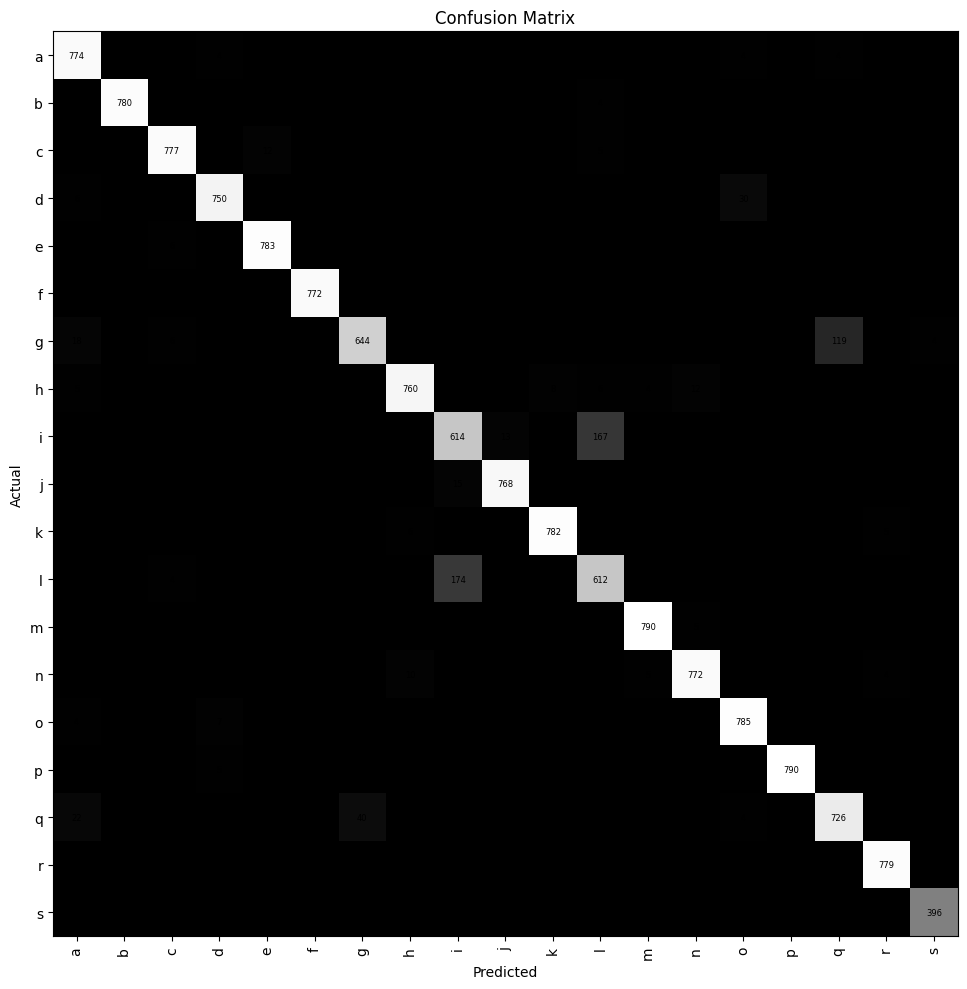

In [11]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Compute confusion matrix
labels_present = sorted(set(all_labels))
cm = confusion_matrix(all_labels, all_preds, labels=labels_present)

# Convert numeric class labels (0–25) → corresponding letters (a–z)
letters = [chr(i + ord('a')) for i in labels_present]

# Create figure for visualization and display as a grayscale image
plt.figure(figsize=(10,10))
plt.imshow(cm, cmap='gray')

# Add titles and axis labels
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(np.arange(len(letters)), letters, rotation=90)
plt.yticks(np.arange(len(letters)), letters)

# Display how many times each actual letter was predicted as each letter
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha='center', va='center',
                 fontsize=6)

plt.tight_layout()
plt.show()

In [12]:
# LOADING + UNZIPPING OUR CUSTOM DATASET

from google.colab import files
files.upload()  # upload data.zip
!unzip newDataset.zip -d my_data

Saving newDataset.zip to newDataset.zip
Archive:  newDataset.zip
   creating: my_data/training/
   creating: my_data/training/aisha/
  inflating: my_data/training/aisha/book_1.png  
  inflating: my_data/training/aisha/book_2.png  
  inflating: my_data/training/aisha/brick_1.png  
  inflating: my_data/training/aisha/brick_2.png  
  inflating: my_data/training/aisha/brick_3.png  
  inflating: my_data/training/aisha/brick_4.png  
  inflating: my_data/training/aisha/brick_5.png  
  inflating: my_data/training/aisha/brick_6.png  
  inflating: my_data/training/aisha/fish_1.png  
  inflating: my_data/training/aisha/fish_2.png  
  inflating: my_data/training/aisha/fly_1.png  
  inflating: my_data/training/aisha/fly_2.png  
  inflating: my_data/training/aisha/fly_3.png  
  inflating: my_data/training/aisha/fly_4.png  
  inflating: my_data/training/aisha/fly_5.png  
  inflating: my_data/training/aisha/fly_6.png  
  inflating: my_data/training/aisha/hand_1.png  
  inflating: my_data/training/aish

In [13]:
import os

train_path = "my_data/training"

# Loop through each folder inside the training directory
for folder in os.listdir(train_path):
    folder_path = os.path.join(train_path, folder)

    # Skip non-folders (like .DS_Store)
    if os.path.isdir(folder_path):
        count = 0

        # Count number of image files in the folder
        for file in os.listdir(folder_path):
            if file.endswith(".png"):
                count += 1

        # Print folder name and number of images inside it
        print(f"{folder}: {count} images")

mariam: 46 images
ela: 46 images
noorah: 46 images
shaikha: 46 images
aisha: 46 images


In [14]:
def segment_characters(image_path, show=True):
    import cv2
    import numpy as np
    import matplotlib.pyplot as plt

    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray, (5,5), 0)

    _, thresh = cv2.threshold(
        blur, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    # Sort left → right
    contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[0])

    # STEP 1: MERGE DOT + STEM (vertical merge for letter i)
    merged = []

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        added = False

        for i, m in enumerate(merged):
            mx, my, mw, mh = cv2.boundingRect(m)

            # vertical alignment condition (same x, dot above stem)
            if abs(x - mx) < 10 and y < my:
                merged[i] = np.concatenate((m, cnt))
                added = True
                break

        if not added:
            merged.append(cnt)

    contours = merged

    # STEP 2: NORMAL FILTERING
    characters = []
    valid_contours = []  # <-- NEW (to track positions for spacing)
    prev_x = -100

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)

        # allow thin letters (like letter 'l')
        if h > 8:

            # remove duplicates but not real letters
            if abs(x - prev_x) < 8:
                continue

            prev_x = x

            char = thresh[y:y+h, x:x+w]

            # padding
            char = cv2.copyMakeBorder(
                char, 10,10,10,10,
                cv2.BORDER_CONSTANT, value=0
            )

            # center
            h_c, w_c = char.shape
            size = max(h_c, w_c)

            square = np.zeros((size, size), dtype=np.uint8)

            y_off = (size - h_c)//2
            x_off = (size - w_c)//2

            square[y_off:y_off+h_c, x_off:x_off+w_c] = char

            char = cv2.resize(square, (28,28))

            characters.append(char)
            valid_contours.append(cnt)  # <-- NEW (store matching contour)

    if show:
        plt.figure(figsize=(10,3))
        for i, ch in enumerate(characters):
            plt.subplot(1, len(characters), i+1)
            plt.imshow(ch, cmap='gray')
            plt.axis('off')
        plt.show()

    return characters, valid_contours  # <-- UPDATED (was only characters)


Processing: img_23.png


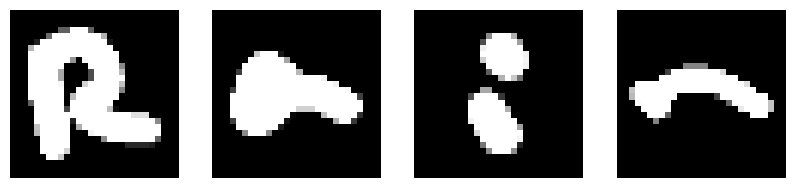

Characters found: 4

Processing: img_12.png


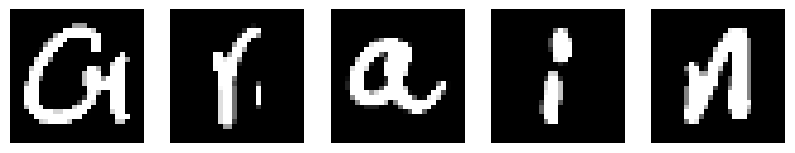

Characters found: 5

Processing: img_25.png


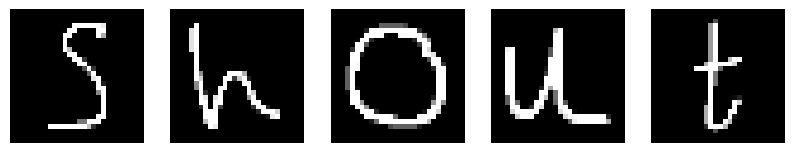

Characters found: 5

Processing: img_22.png


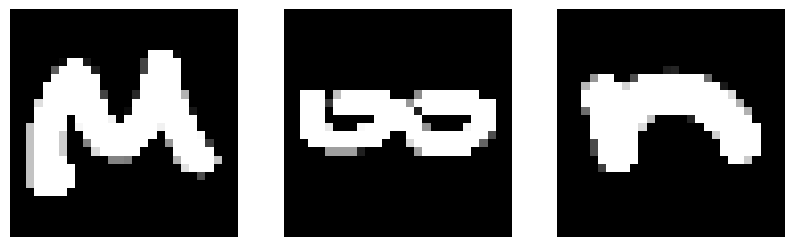

Characters found: 3

Processing: img_21.png


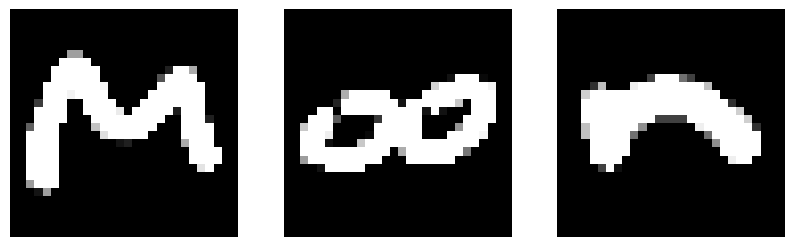

Characters found: 3

Processing: img_27.png


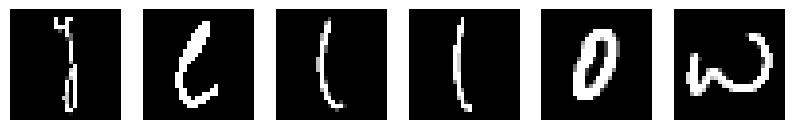

Characters found: 6

Processing: img_10.png


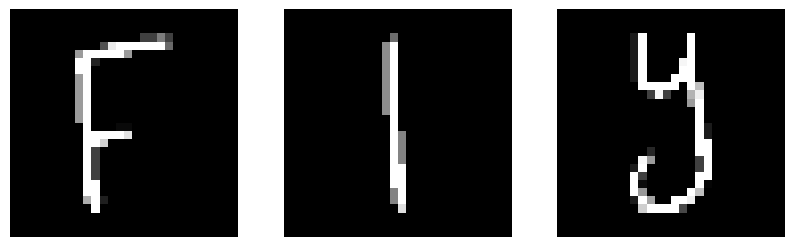

Characters found: 3

Processing: img_13.png


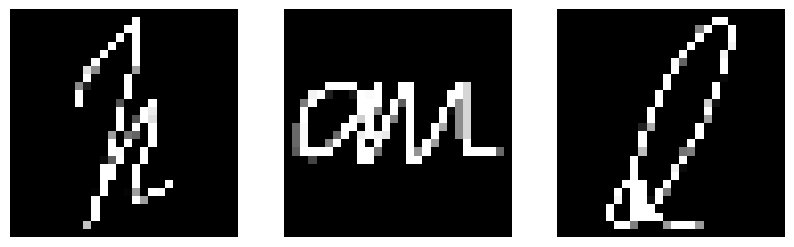

Characters found: 3

Processing: img_19.png


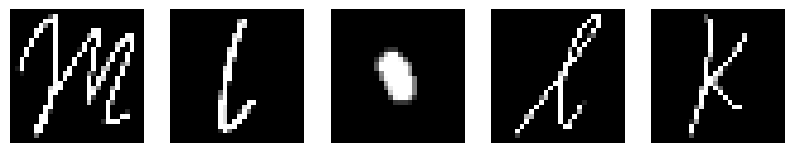

Characters found: 5

Processing: img_05.png


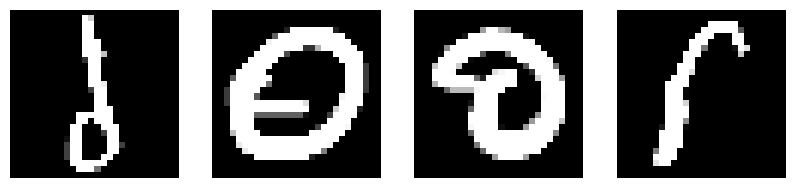

Characters found: 4

Processing: img_20.png


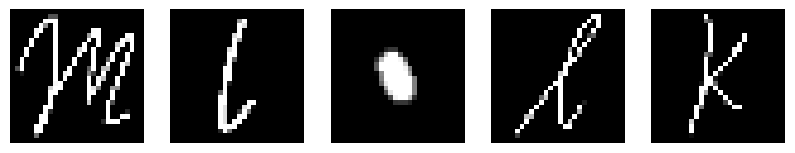

Characters found: 5

Processing: img_29.png


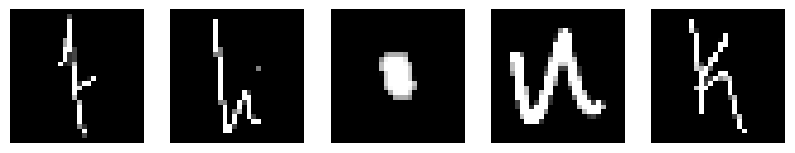

Characters found: 5

Processing: img_02.png


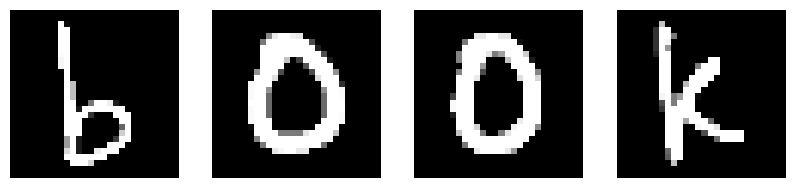

Characters found: 4

Processing: img_04.png


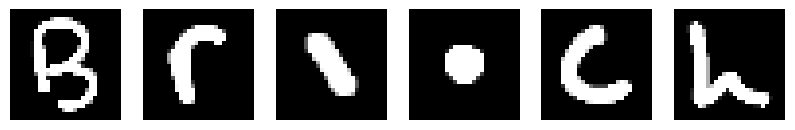

Characters found: 6

Processing: img_14.png


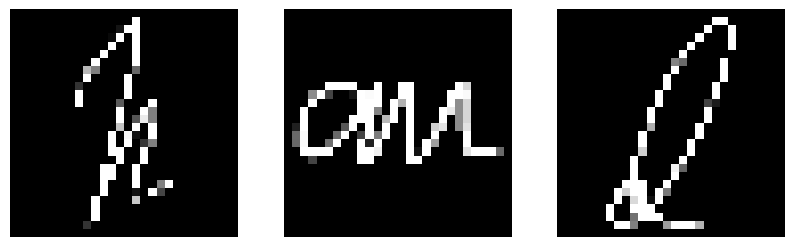

Characters found: 3

Processing: img_11.png


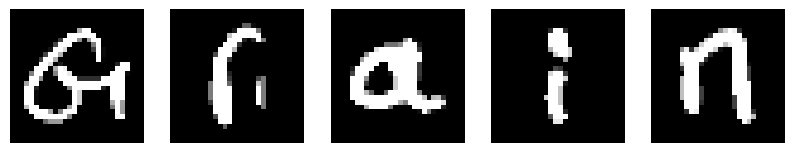

Characters found: 5

Processing: img_01.png


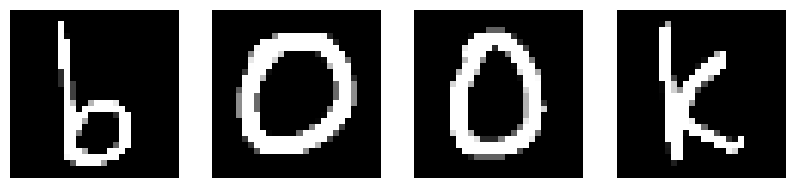

Characters found: 4

Processing: img_18.png


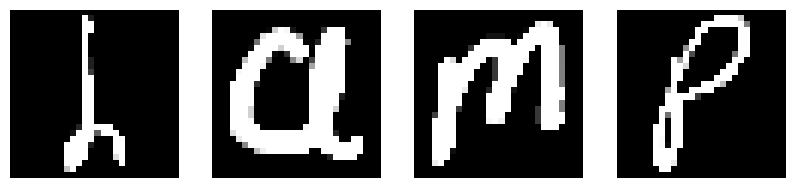

Characters found: 4

Processing: img_30.png


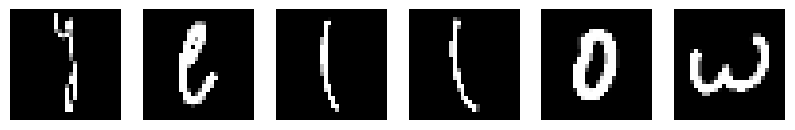

Characters found: 6

Processing: img_08.png


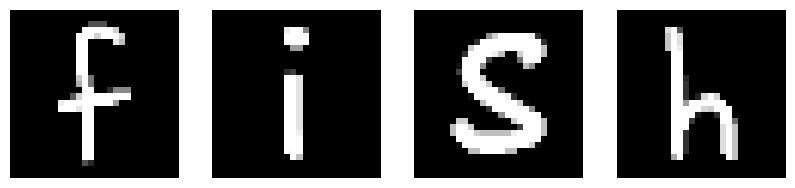

Characters found: 4

Processing: img_15.png


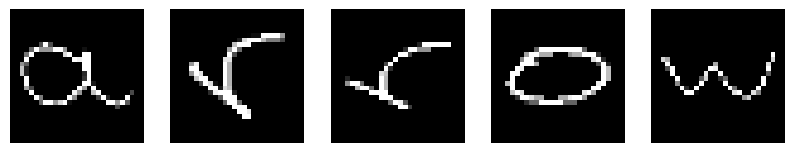

Characters found: 5

Processing: img_26.png


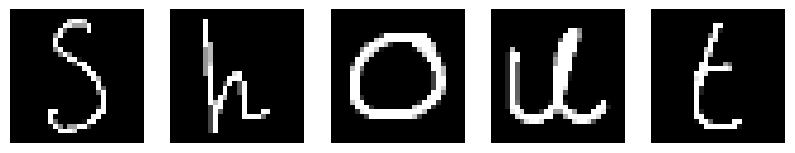

Characters found: 5

Processing: img_07.png


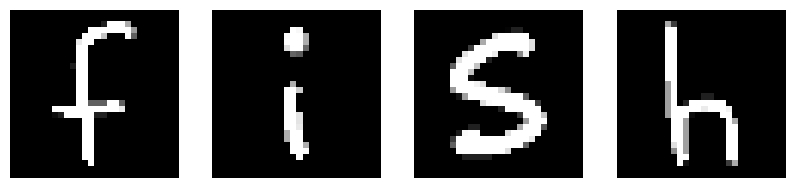

Characters found: 4

Processing: img_09.png


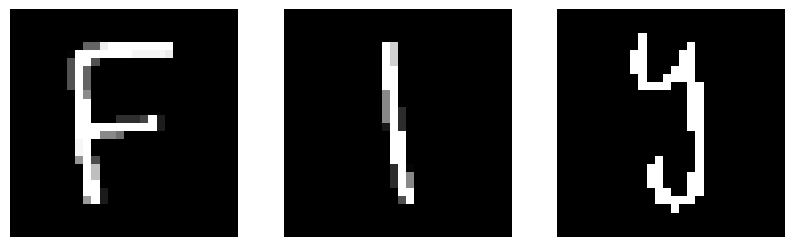

Characters found: 3

Processing: img_17.png


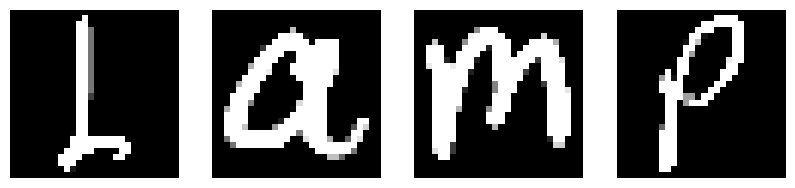

Characters found: 4

Processing: img_06.png


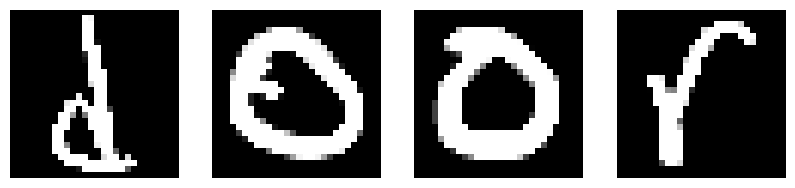

Characters found: 4

Processing: img_03.png


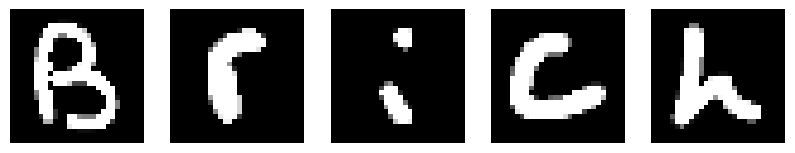

Characters found: 5

Processing: img_28.png


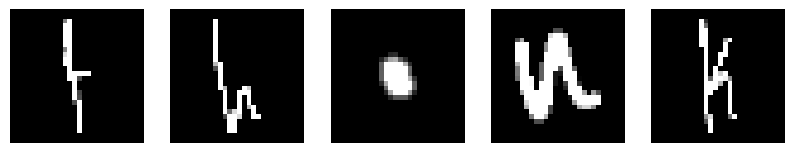

Characters found: 5

Processing: img_16.png


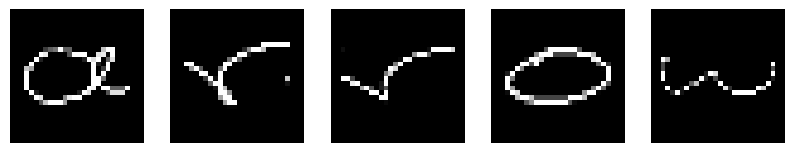

Characters found: 5

Processing: img_24.png


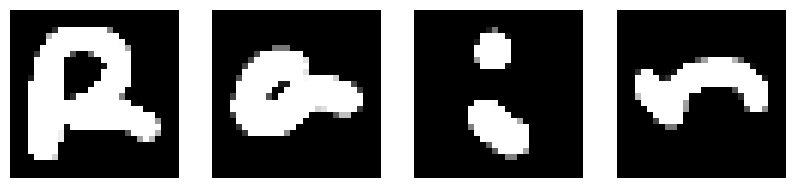

Characters found: 4


In [15]:
test_folder = "my_data/testing"

# Loop through each file in the testing folder
for file in os.listdir(test_folder):

    # Process only image files
    if file.endswith(".png"):
        path = os.path.join(test_folder, file)

        print("\nProcessing:", file)

        # FIX: unpack correctly (characters + contours)
        chars, _ = segment_characters(path)   # <-- FIXED LINE

        print("Characters found:", len(chars))   # Print number of characters detected

In [64]:
import numpy as np   # ✅ REQUIRED
import torch
import torch.nn.functional as F  # ✅ REQUIRED
import cv2

def predict_word(model, image_path):
    # Segment the input word image into individual character images
    chars, contours = segment_characters(image_path, show=False)

    word = ""

    # Store confidence for each character
    char_confidences = []

    # Get bounding boxes for spacing detection
    boxes = [cv2.boundingRect(c) for c in contours]

    # Sort left → right (safety)
    boxes = sorted(boxes, key=lambda b: b[0])

    # Compute gaps between characters
    gaps = []
    for i in range(1, len(boxes)):
        prev_x, prev_y, prev_w, prev_h = boxes[i-1]
        curr_x, curr_y, curr_w, curr_h = boxes[i]

        gap = curr_x - (prev_x + prev_w)
        gaps.append(gap)

    # =========================
    # 🔥 IMPROVED SPACE LOGIC
    # =========================
    import numpy as np

    if len(gaps) > 0:
        median_gap = np.median(gaps)
        max_gap = max(gaps)

        widths = [w for (_, _, w, _) in boxes]
        avg_width = sum(widths) / len(widths)

        # More aggressive detection (since your gaps are real)
        space_threshold = max(median_gap * 1.8, avg_width * 0.9)

        # Ensure it's one of the largest gaps
        gap_ratio_threshold = 0.7
    else:
        space_threshold = 999
        max_gap = 0
        gap_ratio_threshold = 1

    # Loop through each segmented character
    for i, ch in enumerate(chars):
        ch = ch / 255.0                                               # Normalize pixel values to match training preprocessing
        tensor = torch.tensor(ch).unsqueeze(0).unsqueeze(0).float()   # Convert to tensor and add batch + channel dimensions → [1, 1, 28, 28]

        # Predict character using trained CNN model (CharCNN)
        output = model(tensor)

        # Convert raw output → probabilities
        probs = F.softmax(output, dim=1)

        # Get predicted class and its confidence
        confidence, pred = torch.max(probs, dim=1)

        # Convert predicted class index (0–25) → corresponding letter (a–z)
        letter = chr(pred.item() + ord('a'))

        # Add predicted letter to form the full word
        word += letter

        # Store confidence value
        char_confidences.append((letter, confidence.item()))

        # 🚨 SPACE DETECTION (FIXED)
        if i < len(gaps):
            if gaps[i] > space_threshold and gaps[i] > max_gap * gap_ratio_threshold:
                word += " "

    # Compute average confidence across all characters
    if len(char_confidences) > 0:
        avg_confidence = sum(c for _, c in char_confidences) / len(char_confidences)
    else:
        avg_confidence = 0

    # Return word + per-character confidence + overall confidence
    return word.strip(), char_confidences, avg_confidence

In [65]:
import difflib

def smart_correct_word(pred, char_confidences, dictionary):

    # -----------------------------
    # STEP 1: PROTECT GOOD OUTPUT
    # -----------------------------
    avg_conf = sum(conf for _, conf in char_confidences) / len(char_confidences)

    if avg_conf >= 0.9 and pred in dictionary:
        return pred

    # -----------------------------
    # STEP 2: GET CANDIDATES
    # -----------------------------
    candidates = difflib.get_close_matches(pred, dictionary, n=10, cutoff=0.6)

    if pred not in candidates:
        candidates.append(pred)

    best_word = pred
    best_score = -999

    # -----------------------------
    # STEP 3: SCORE
    # -----------------------------
    for word in candidates:

        # allow only ±1 length difference
        if abs(len(word) - len(pred)) > 1:
            continue

        score = 0

        # length preference
        if len(word) == len(pred):
            score += 2

        # character matching
        for i in range(min(len(word), len(char_confidences))):
            predicted_char, conf = char_confidences[i]

            if word[i] == predicted_char:
                score += conf * 2
            else:
                score -= (1 - conf)

        # small penalty for length mismatch
        if len(word) != len(pred):
            score -= 0.5

        # 🔥 frequency boost (IMPORTANT)
        score += zipf_frequency(word, "en")

        # pick best
        if score > best_score:
            best_score = score
            best_word = word

    # -----------------------------
    # STEP 4: SAFETY (VERY IMPORTANT)
    # -----------------------------
    # only accept correction if clearly better
    if best_word != pred and best_score > 1:
        return best_word

    return pred

In [66]:
def align_word_with_confidence(word, char_confidences):

    aligned = []

    for j in range(len(word)):
        if j < len(char_confidences):
            pred_char, conf = char_confidences[j]

            if word[j] == pred_char:
                aligned.append((word[j], conf))
            else:
                aligned.append((word[j], conf * 0.6))
        else:
            aligned.append((word[j], 0.5))

    return aligned

In [67]:
# PREPARE DATA FOR FINETUNING

training_folder = "my_data/training"

# Lists to store extracted character images and their labels
char_images = []
char_labels = []

# Loop through each folder in training folder
for person in os.listdir(training_folder):
    person_path = os.path.join(training_folder, person)

    # Skip non-folder files
    if not os.path.isdir(person_path):
        continue

    # Skip non-folder files
    for file in os.listdir(person_path):
        if file.endswith(".png"):

            path = os.path.join(person_path, file)

            # Extract word label from filename (for example: "grain_1.png" → "grain")
            word = file.split("_")[0]

            # Segment word image into individual characters
            chars, _ = segment_characters(path, show=False)   # ✅ FIXED LINE

            # Only use samples where segmentation matches word length
            if len(chars) == len(word):

                # Pair each character image with its correct label
                for ch_img, ch_label in zip(chars, word):
                    char_images.append(ch_img)
                    char_labels.append(ord(ch_label) - ord('a'))

In [68]:
# CUSTOM DATASET (FOR FINETUNING)

class CustomCharDataset(Dataset):
    # Initialize dataset with images and labels
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    # Return dataset size
    def __len__(self):
        return len(self.images)

    # Get one sample (image + label)
    def __getitem__(self, idx):
        img = self.images[idx] / 255.0
        img = torch.tensor(img).unsqueeze(0).float()
        label = self.labels[idx]
        return img, label

In [69]:
# FINETUNING (ADAPT MODEL TO OUR DATA)

# Create dataset and dataloader for character-level data
custom_dataset = CustomCharDataset(char_images, char_labels)
custom_loader = DataLoader(custom_dataset, batch_size=32, shuffle=True)

# Set model to training mode
model.train()

# Define optimizer (smaller learning rate for fine-tuning)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss()

for epoch in range(3):
    total_loss = 0

    for images, labels in custom_loader:
        outputs = model(images)              # Forward pass
        loss = criterion(outputs, labels)    # Compute loss

        optimizer.zero_grad()                # Clear gradients
        loss.backward()                      # Backpropagation
        optimizer.step()                     # Update weights

        total_loss += loss.item()

    print(f"Fine-tune Epoch {epoch+1}, Loss: {total_loss/len(custom_loader)}")

Fine-tune Epoch 1, Loss: 0.013396151755781223
Fine-tune Epoch 2, Loss: 0.00797168415398725
Fine-tune Epoch 3, Loss: 0.014645169707849466


In [70]:
# SAVE FINETUNED MODEL
torch.save(model.state_dict(), "char_model_finetuned.pth")

# LOAD FINETUNED MODEL FOR TESTING
model.load_state_dict(torch.load("char_model_finetuned.pth"))

# Set to evaluation mode for inference
model.eval()

CharCNN(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=1152, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128,

In [71]:
true_labels = {
    "img_01.png": "book",
    "img_02.png": "book",
    "img_03.png": "brick",
    "img_04.png": "brick",
    "img_05.png": "door",
    "img_06.png": "door",
    "img_07.png": "fish",
    "img_08.png": "fish",
    "img_09.png": "fly",
    "img_10.png": "fly",
    "img_11.png": "grain",
    "img_12.png": "grain",
    "img_13.png": "hand",
    "img_14.png": "hand",
    "img_15.png": "arrow",
    "img_16.png": "arrow",
    "img_17.png": "lamp",
    "img_18.png": "lamp",
    "img_19.png": "milk",
    "img_20.png": "milk",
    "img_21.png": "moon",
    "img_22.png": "moon",
    "img_23.png": "rain",
    "img_24.png": "rain",
    "img_25.png": "shout",
    "img_26.png": "shout",
    "img_27.png": "yellow",
    "img_28.png": "think",
    "img_29.png": "think",
    "img_30.png": "yellow"
}

In [72]:
# Function to assign color based on confidence level
def get_color(conf):
    if conf >= 0.9:
        return "green"
    elif conf >= 0.7:
        return "orange"
    else:
        return "red"

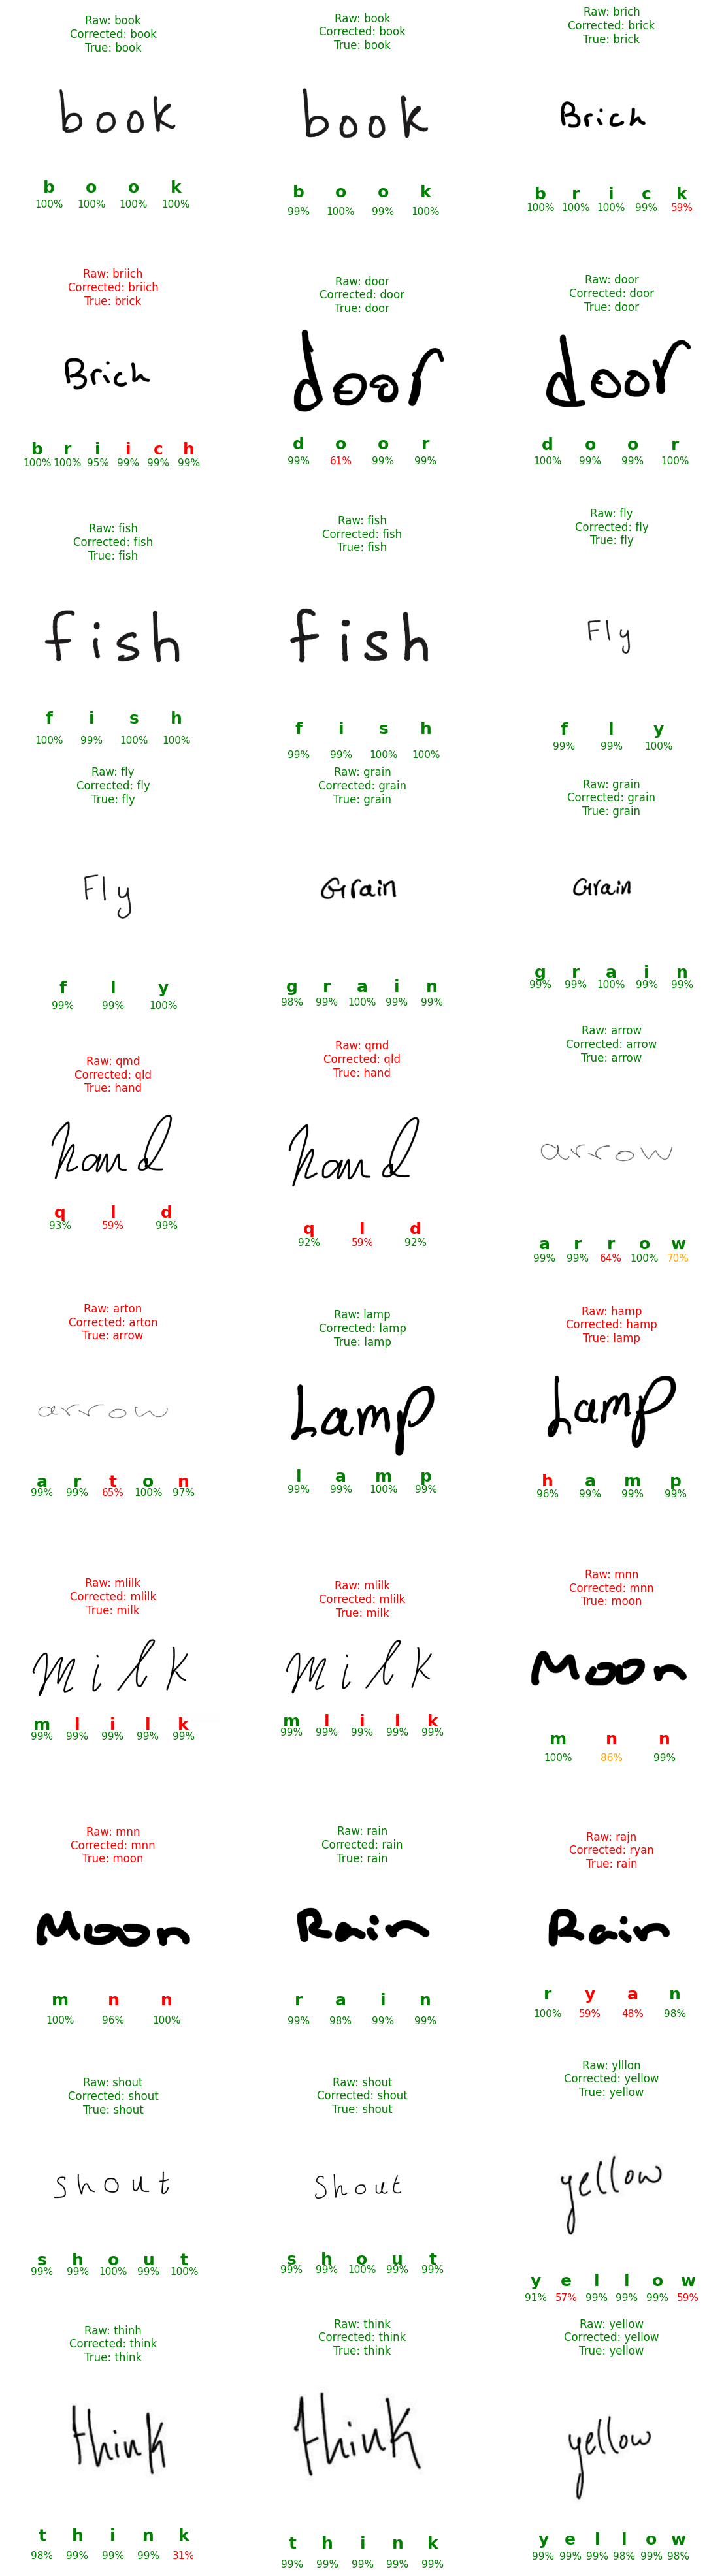


Final Word Accuracy: 20/30 = 0.6667


In [73]:
import matplotlib.pyplot as plt
import cv2

correct = 0
total = 0

test_folder = "my_data/testing"
files = sorted([f for f in os.listdir(test_folder) if f.endswith(".png")])

cols = 3
rows = (len(files) + cols - 1) // cols

plt.figure(figsize=(12, rows * 4))

for i, file in enumerate(files):
    path = os.path.join(test_folder, file)

    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    pred, char_confidences, avg_conf = predict_word(model, path)
    corrected = smart_correct_word(pred, char_confidences, dictionary)

    true = true_labels[file]
    true_no_space = true.replace(" ", "")

    is_correct = (corrected == true)
    title_color = "green" if is_correct else "red"

    correct += int(is_correct)
    total += 1

    plt.subplot(rows, cols, i+1)
    plt.imshow(img)

    plt.title(
        f"Raw: {pred}\nCorrected: {corrected}\nTrue: {true}",
        color=title_color,
        fontsize=12
    )

    final_chars = align_word_with_confidence(corrected, char_confidences)

    img_width = img.shape[1]
    n_chars = len(final_chars)

    spacing = img_width // (n_chars + 1) if n_chars > 1 else img_width // 2

    for j, (ch, conf) in enumerate(final_chars):
        x = (j + 1) * spacing

        if j < len(true_no_space) and ch == true_no_space[j]:
            char_color = "green"
        else:
            char_color = "red"

        plt.text(
            x,
            img.shape[0] + 30,
            ch,
            color=char_color,
            fontsize=18,
            fontweight='bold',
            ha='center'
        )

    for j, (ch, conf) in enumerate(final_chars):
        x = (j + 1) * spacing

        plt.text(
            x,
            img.shape[0] + 70,
            f"{int(conf*100)}%",
            color=get_color(conf),
            fontsize=11,
            ha='center'
        )

    plt.axis('off')

plt.tight_layout(pad=4.0)
plt.show()

print(f"\nFinal Word Accuracy: {correct}/{total} = {correct/total:.4f}")

In [74]:
# Character accuracy inside words

# Initialize counters
total_chars = 0
correct_chars = 0

# Loop through each test
for file in true_labels:

    pred_word, _, _ = predict_word(model, os.path.join(test_folder, file))
    true = true_labels[file]

    # Compare each predicted character with the true character
    for p, t in zip(pred_word, true):
        if p == t:
            correct_chars += 1
        total_chars += 1

# Compute accuracy
char_acc = correct_chars / total_chars
print(f"Character Accuracy (Word-Level): {char_acc:.4f}")

Character Accuracy (Word-Level): 0.7969


Saving img_24.jpeg to img_24 (2).jpeg


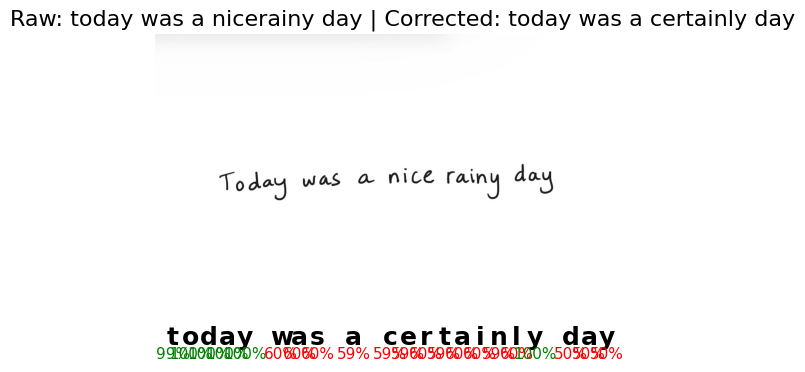

Raw prediction: today was a nicerainy day
Corrected sentence: today was a certainly day
Average confidence: 0.999


In [86]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# 🔥 Predict sentence
pred, char_confidences, avg_conf = predict_word(model, image_path)

# -----------------------------
# 🚨 HANDLE EMPTY PREDICTION
# -----------------------------
if pred.strip() == "" or len(char_confidences) == 0:
    print("⚠️ No text detected or segmentation failed")

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.axis('off')
    plt.title("No text detected", fontsize=16)
    plt.show()

else:
    # -----------------------------
    # 🔥 SPLIT INTO WORDS
    # -----------------------------
    words = pred.split()

    corrected_words = []
    char_index = 0
    all_final_chars = []

    for word in words:
        length = len(word)

        # get matching confidences
        word_conf = char_confidences[char_index:char_index + length]

        # 🚨 HANDLE EMPTY WORD CONFIDENCE
        if len(word_conf) == 0:
            corrected_word = word
        else:
            corrected_word = smart_correct_word(word, word_conf, dictionary)

        corrected_words.append(corrected_word)

        # align characters for visualization
        final_chars = align_word_with_confidence(corrected_word, word_conf)
        all_final_chars.extend(final_chars)

        # add visual space
        all_final_chars.append((" ", 1.0))

        char_index += length + 1

    corrected_sentence = " ".join(corrected_words)

    # -----------------------------
    # DISPLAY IMAGE
    # -----------------------------
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.axis('off')

    plt.title(f"Raw: {pred} | Corrected: {corrected_sentence}", fontsize=16)

    # -----------------------------
    # DISPLAY CHARACTERS
    # -----------------------------
    img_width = img.shape[1]
    n_chars = len(all_final_chars)

    spacing = img_width // (n_chars + 1) if n_chars > 1 else img_width // 2

    for j, (ch, conf) in enumerate(all_final_chars):
        if ch == " ":
            continue

        x = (j + 1) * spacing

        plt.text(
            x,
            img.shape[0] + 30,
            ch,
            color="black",
            fontsize=18,
            fontweight='bold',
            ha='center'
        )

    for j, (ch, conf) in enumerate(all_final_chars):
        if ch == " ":
            continue

        x = (j + 1) * spacing

        plt.text(
            x,
            img.shape[0] + 70,
            f"{int(conf*100)}%",
            color=get_color(conf),
            fontsize=11,
            ha='center'
        )

    plt.show()

    # -----------------------------
    # PRINT DETAILS
    # -----------------------------
    print("Raw prediction:", pred)
    print("Corrected sentence:", corrected_sentence)
    print("Average confidence:", round(avg_conf, 3))